# Baseline Models (TF-IDF)

Training Logistic Regression and Random Forest models as baselines.

In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Load processed data
df = pd.read_csv('../data/processed.csv')

# Drop NA rows just in case
df = df.dropna(subset=['processed_text', 'label'])


## Vectorization and Splitting

In [2]:
# Use TF-IDF vectorizer (max 5000 features for efficiency)
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['processed_text'])
y = df['label']

# 85/15 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")


Train size: 38155, Test size: 6734


## Logistic Regression Model

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      3213
           1       0.99      0.98      0.99      3521

    accuracy                           0.99      6734
   macro avg       0.99      0.99      0.99      6734
weighted avg       0.99      0.99      0.99      6734



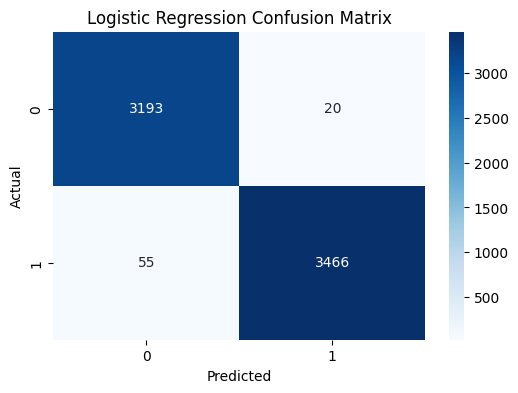

In [3]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

print("Logistic Regression Classification Report:")
print(classification_report(y_test, lr_preds))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, lr_preds), annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## Random Forest Model

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3213
           1       1.00      1.00      1.00      3521

    accuracy                           1.00      6734
   macro avg       1.00      1.00      1.00      6734
weighted avg       1.00      1.00      1.00      6734



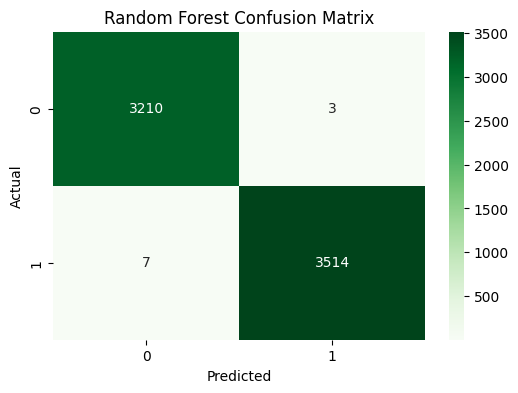

In [4]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("Random Forest Classification Report:")
print(classification_report(y_test, rf_preds))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
